In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import itertools as it
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
#Testing over a set of tech companies, search can easily be extended by adding more companies.
Companies=['NVDA','AAPL','MSFT','AVGO','AMD','GOOG','AMZN','META']
#Stock prices of companies over a 5 year period at close.
RealisationMatrix=yf.download(Companies,period='5y')['Close']

[*********************100%***********************]  8 of 8 completed


In [2]:
RealisationMatrix.head()

Ticker,AAPL,AMD,AMZN,AVGO,GOOG,META,MSFT,NVDA
Date,,,,,,,,
2021-07-28,141.319550,97.930000,181.516006,43.484436,135.189575,370.030548,274.684326,19.435778
2021-07-29,141.962875,102.949997,179.996002,44.072544,135.347198,355.200806,274.953156,19.594223
2021-07-30,142.177338,106.190002,166.379501,44.189980,134.039215,353.198364,273.427185,19.431789
2021-08-02,141.845932,108.629997,166.574005,44.124435,134.801010,348.886230,273.340820,19.681927
2021-08-03,143.639465,112.559998,168.311996,44.316525,135.088943,348.182465,275.548157,19.746700


In [3]:
#Dropping incomplete entires, and taking log for scale-invariance
#Splitting data 80/20 for training/testing model
CleanMatrix=RealisationMatrix.dropna()
split=int(len(CleanMatrix)*0.80)
TrainMatrix=CleanMatrix.iloc[:split]
TestMatrix=CleanMatrix.iloc[split:]

CleanMatrixLog=np.log(CleanMatrix)
TrainMatrixLog=CleanMatrixLog.iloc[:split]
TestMatrixLog=CleanMatrixLog.iloc[split:]

In [4]:
#Calculates number of days for the divergence of a pair of stocks from their mean relationship to half
#Achieved via Ornstein-Uhlenbeck process
def calculate_half_life(spread):
    ds=spread.diff() #change in spread (Delta S_t)
    lag=spread.shift(1) #lagged spread (S_{t-1})

    #Create dataframe to drop NaNs for correct alignment
    df=pd.DataFrame({'ds': ds,'lag':lag}).dropna()
    
    #Fit OLS regression: Delta S_t = alpha + gamma * S_{t-1} + e_t
    model = sm.OLS(df['ds'],sm.add_constant(df['lag'])).fit()
    gamma = model.params.iloc[1]    

    #returns half life, valid iff gamma < 0 
    return -np.log(2)/gamma if gamma<0 else np.inf

In [5]:
#Find cointegrated pairs with p-value under threshold
#Takes logged input for prices
def pair(priceslogged,p_threshold=0.05):
    results=[]
    
    #Iterating for each unique pair of stocks
    for A,B in it.combinations(priceslogged.columns,2):
        y=priceslogged[A]
        x=priceslogged[B]
        
        #Engle-Granger test, low p proves long term equilibrium
        p_value=coint(y,x)[1]
        if p_value<p_threshold:
            
            #Computing half life and Beta (hedge ratio) of model A=alpha+beta*B (Static Cointegrating Regression)
            model = sm.OLS(y, sm.add_constant(x)).fit()
            alpha = model.params.iloc[0]
            beta  = model.params.iloc[1]
            spread = y - (alpha + beta * x)

            #Use calculated spread to calculate half life of cointegrated pairs
            hl = calculate_half_life(spread)            
            results.append({'Pair': f"{A} - {B}",'p_value': round(p_value, 4),'beta': round(beta, 4),'half_life_days': round(hl, 1)})
    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)        

In [6]:
pair(TrainMatrixLog)

,Pair,p_value,beta,half_life_days
0,AMZN - GOOG,0.0005,1.1909,18.5
1,META - MSFT,0.0208,2.2577,33.8
2,MSFT - NVDA,0.0308,0.2593,27.5
3,GOOG - META,0.0393,0.3728,28.7
4,AAPL - NVDA,0.0414,0.1913,30.0


In [7]:
#Apply kalman filter to a pair of stocks to create a series of Beta's (Hedge Ratios) and the corresponding spread/spread std
#x,y = stock 1,stock 2, delta alpha/beta = Process variance (dictates how fast Alpha/Beta can change), 
#R = Measurement Noise Variance (Represents level of background noise), warmup = number of days to train our intial Beta over
#Takes logged prices as input, z window = lookback window used to calculate certain metrics
#Two modes, one for warmup and one for just taking an intial value of alpha and beta which will be used later
#a,b=initial alpha,beta Pa,Pb=corresponding intial estimate of variance of error
def kalman_filter(xlogged,ylogged,delta_alpha=1e-4,delta_beta=1e-4,R=1,warmup=30,z_window=30,a=None,b=None,Pa=None,Pb=None):
    n=len(xlogged)
    alphas=np.zeros(n)
    betas=np.zeros(n)
    spreads=np.zeros(n)
    
    if warmup>0:
        #Initialse parameters over warmup period using OLS regression
        warmup_x = sm.add_constant(xlogged.iloc[:warmup])
        warmup_y = ylogged.iloc[:warmup]
        ols=sm.OLS(warmup_y, warmup_x).fit()
        alpha=ols.params.iloc[0]
        alphas[:warmup]=alpha
        beta=ols.params.iloc[1]
        betas[:warmup]=beta
        spreads[:warmup]=warmup_y-(alpha+beta*xlogged.iloc[:warmup])
        P_alpha=ols.bse.iloc[0]**2 #Estimate variance of error of Alpha
        P_beta=ols.bse.iloc[1]**2 #Estimate variance of error of Beta
            
    else:
        #Starting from inputed parameter values
        alpha=a
        beta=b
        P_alpha=Pa
        P_beta=Pb
 
    Q_alpha=delta_alpha/(1-delta_alpha) #Process noise covariance of Alpha
    Q_beta=delta_beta/(1-delta_beta) #Process noise covariance of Beta

    for t in range(warmup,n):
        xt=xlogged.iloc[t]
        yt=ylogged.iloc[t]
        
        #Update Beta
        et=yt-(alpha+beta*xt) #Spread estimate (prior)
        St_beta=((xt**2)*P_beta)+R #Measurement variance
        Kt_beta=(xt*P_beta)/St_beta #Kalman gain
        beta=beta+(Kt_beta*et) #Updating Beta value
        P_beta=(1-Kt_beta*xt)*P_beta+Q_beta #Updating variance of error

        #Update Alpha
        et_new=yt-(alpha+beta*xt) #Updated spread estimate 
        St_alpha=P_alpha+R
        Kt_alpha=P_alpha/St_alpha
        alpha=alpha+(Kt_alpha*et_new)
        P_alpha=(1-Kt_alpha)*P_alpha+Q_alpha

        alphas[t]=alpha
        betas[t]=beta
        spreads[t]=et_new

    alpha_series=pd.Series(alphas,index=xlogged.index,name='Alpha')
    beta_series=pd.Series(betas,index=xlogged.index,name="Beta")
    spread_series=pd.Series(spreads,index=xlogged.index,name="Spread")
    
    #Statistics for Zscore
    rolling_mean=spread_series.rolling(window=z_window).mean()
    rolling_std=spread_series.rolling(window=z_window).std()
    z_score_series=(spread_series-rolling_mean)/rolling_std
    valid_idx=z_score_series.dropna().index 
    end_state={'a':alpha,'b':beta,'Pa':P_alpha,'Pb':P_beta} #Used for starting test data
    return alpha_series.loc[valid_idx],beta_series.loc[valid_idx],spread_series.loc[valid_idx],z_score_series.loc[valid_idx],end_state

In [8]:
stockxlogged=TrainMatrixLog['AMZN']
stockylogged=TrainMatrixLog['GOOG']
alpha_AG,beta_AG,spread_AG,z_AG,end_AG=kalman_filter(stockxlogged,stockylogged)
summary=pd.DataFrame({'Alpha':alpha_AG,'Beta':beta_AG, 'Spread':spread_AG,'Z-Score':z_AG})
summary.tail(5).style.format({'Aplha':'{:.4f}','Beta':'{:.4f}','Spread':'{:.2%}','Z-Score':'{:.2f}'})

,Alpha,Beta,Spread,Z-Score
Date,,,,
2025-07-18 00:00:00,3.482410,0.3141,3.78%,1.02
2025-07-21 00:00:00,3.482981,0.3147,5.74%,1.85
2025-07-22 00:00:00,3.483588,0.3153,6.10%,1.85
2025-07-23 00:00:00,3.484117,0.3159,5.31%,1.42
2025-07-24 00:00:00,3.484644,0.3164,5.30%,1.39


In [9]:
#Generating trading position based on Z_scores from Kalman Filter
#Enter trade if Z score exceeds entry value, exit trade if below exit value (of same sign +-)
#0=exit/close position, 1 = (buy y, short x), -1 = (short y, buy x)
#Stop loss implemented incase pair ceases to be cointegration, ie they do not return to equilibrium
def signals(Z_scores,entry=1,exit=0.25,stop=3):
    n=len(Z_scores)
    positions=np.zeros(n)
    current_position=0
    for i in range(n):
        z=Z_scores.iloc[i]
        if current_position == 1:
            if z >= -exit or z <= -stop:
                current_position = 0
        elif current_position == -1:
            if z <= exit or z >= stop:
                current_position = 0    
        elif current_position == 0:
            if entry <= z < stop:
                current_position = -1  # Short Y, Buy X
            elif -stop < z <= -entry:
                current_position = 1   # Buy Y, Short X
        positions[i] = current_position        
    return  pd.Series(positions,index=Z_scores.index,name="Position")

In [10]:
#Calucating returns, taking logged prices as input, postions,alphas & betas procduced using previous functions
#capital=initial starting capital, leverage=portfolio leverage factor, rf_annual=annual risk free rate for unused cash
#t_cost=transaction cost per trade
def returns(xlogged,ylogged,positions,alphas,betas,capital=10000,leverage=2.0,rf_annual=0.045,t_cost=0.001):
    idx=positions.index
    
    #Aligning daily values for each set of parameters, noting logged values approximate percentage returns
    dx=xlogged.loc[idx].diff().fillna(0)
    dy=ylogged.loc[idx].diff().fillna(0)
    da=alphas.loc[idx].diff().fillna(0)
    traded_pos=positions.shift(1).fillna(0)
    traded_beta=betas.loc[idx].shift(1).fillna(betas.iloc[0])

    #Calculating trade returns
    spread_return=(dy-(da+traded_beta*dx))/(1+traded_beta.abs())
    returns=traded_pos*spread_return*leverage

    #Calculating cost on position changes
    switches=positions.diff().abs().fillna(0)
    costs=switches*t_cost*leverage

    #Calculating interest on unused cash
    rf_daily=rf_annual/252
    cash_days=(traded_pos == 0).astype(int)
    cash_returns=cash_days*rf_daily

    #Computing net return and compounding portfolio value
    net=returns+cash_returns-costs
    portfolio_value=capital*(1+net).cumprod()

    return pd.DataFrame({'Traded Position':traded_pos,'Net Return':net,'Portfolio Value':portfolio_value})

Traded Position
 0.0    368
-1.0    305
 1.0    300
Name: count, dtype: int64
            Traded Position  Net Return  Portfolio Value
Date                                                    
2025-07-11              0.0    0.000179     29819.151740
2025-07-14              0.0    0.000179     29824.476589
2025-07-15              0.0    0.000179     29829.802388
2025-07-16              0.0   -0.001821     29775.469534
2025-07-17             -1.0   -0.005658     29606.990472
2025-07-18             -1.0   -0.004839     29463.727042
2025-07-21             -1.0   -0.034534     28446.238380
2025-07-22             -1.0   -0.010534     28146.576808
2025-07-23             -1.0    0.007285     28351.631123
2025-07-24             -1.0   -0.004337     28228.664091


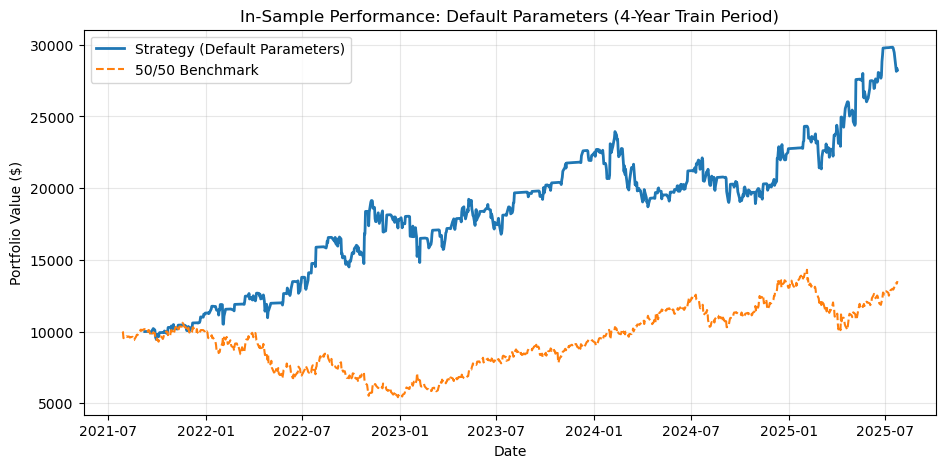

In [11]:
pos_AG=signals(z_AG,entry=1,exit=0.25)
growth_AG=returns(stockxlogged,stockylogged,pos_AG,alpha_AG,beta_AG)
print(growth_AG['Traded Position'].value_counts())
print(growth_AG.tail(10))

# 1. Calculate 50/50 Benchmark for Training Period
px_tr, py_tr = np.exp(stockxlogged), np.exp(stockylogged)
benchmark_tr = 5000 * (px_tr / px_tr.iloc[0]) + 5000 * (py_tr / py_tr.iloc[0])

plt.figure(figsize=(11, 5))
plt.plot(growth_AG['Portfolio Value'], label='Strategy (Default Parameters)',linewidth=2)
plt.plot(benchmark_tr, label='50/50 Benchmark', linestyle='--', linewidth=1.5)

plt.title('In-Sample Performance: Default Parameters (4-Year Train Period)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [12]:
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#From here we attempt to backtest to find optimal parameter values, however we will note straight away this leads to some overfitting, and
#a significantly decreased PnL. However, the risk of the trades dramatically decrease and in order to captialise on such property, we 
#would need to implement trading over multiple pairs of stocks
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

#Computing metrics in order to test parameter values
#Takes dataframe outputted from returns() as input
def metrics(returns_df,capital=10000):
    net_returns=returns_df['Net Return']
    portfolio_value=returns_df['Portfolio Value']
    traded_pos=returns_df['Traded Position']

    #Annualizied Sharpe Ratio: Quantifies whether returns are worth the risk
    R_mean=net_returns.mean()
    R_std=net_returns.std()
    SR=((R_mean/R_std*np.sqrt(252)) if R_std > 0 else 0)

    #Net PnL
    end=portfolio_value.iloc[-1]
    net_pnl=end-capital

    #Maximun Drawdown: Largest drop in portfolio value
    Pmax=portfolio_value.cummax()
    drawdown=(portfolio_value-Pmax)/Pmax
    max_drawdown=drawdown.min()*100

    #Calmar Ratio
    years=len(returns_df)/252
    c=(end/capital)**(1/years)-1 if years > 0 else 0
    CR=c/(abs(max_drawdown)/100) if abs(max_drawdown) > 0 else 0

    #Trade Execution: Number of profitable days vs Number of trading days
    active=net_returns[traded_pos != 0]
    total=len(active)
    if total > 0:
        win=(active>0).sum()
        winrate=win/total*100 #winrate as percentage
    elif total == 0:
        winrate=0
    trades=((traded_pos!=0)&(traded_pos.shift(1).fillna(0)==0)).sum()

    return {"Net PnL": f"${net_pnl:,.2f}","Ending Portfolio Value": f"${end:,.2f}","Sharpe Ratio": round(SR, 2),
        "Calmar Ratio": round(CR, 2),"Max Drawdown": f"{max_drawdown:.2f}%","Win Rate": f"{winrate:.2f}%",
        "Total Trades": trades}

In [13]:
pd.Series(metrics(growth_AG), name="Value")

Net PnL                   $18,228.66
Ending Portfolio Value    $28,228.66
Sharpe Ratio                    1.01
Calmar Ratio                    1.37
Max Drawdown                 -22.59%
Win Rate                      55.37%
Total Trades                      72
Name: Value, dtype: object

In [14]:
#Computing metrics for a range of paramter values
#Typical paramters that can be varied over are entry/exit thresholds,lookback window (z_window) and process noise variance (delta_beta)
#but you can also consider the stop loss and delta_alpha. All other parameters are kept at default throughout program.
def parasearch(xlogged,ylogged,parameters,capital=10000,warmup=30,leverage=2,rf_annual=0.045,t_cost=0.001):
    #Create all parameter combinations
    keys=list(parameters.keys())
    values=list(parameters.values())
    combos=[dict(zip(keys,v)) for v in it.product(*values)]
    results=[]

    for C in combos:
        C_entry=C.get('entry',1)
        C_exit=C.get('exit',0.25)
        C_z_window=C.get('z_window',30)
        C_delta_alpha=C.get('delta_alpha',1e-4)
        C_delta_beta=C.get('delta_beta',1e-4)
        C_stop=C.get('stop',3)

        alpha_s,beta_s,_,z_s,_=kalman_filter(xlogged,ylogged,delta_alpha=C_delta_alpha,delta_beta=C_delta_beta,warmup=warmup,
                                          z_window=C_z_window)
        pos_s=signals(z_s,entry=C_entry,exit=C_exit,stop=C_stop)
        returns_df=returns(xlogged,ylogged,pos_s,alpha_s,beta_s,capital=capital,leverage=leverage,rf_annual=rf_annual,t_cost=t_cost)
        tested_metrics=metrics(returns_df,capital=capital)
        
        row={**C,**tested_metrics}
        results.append(row)

    results_df=pd.DataFrame(results)
    return results_df

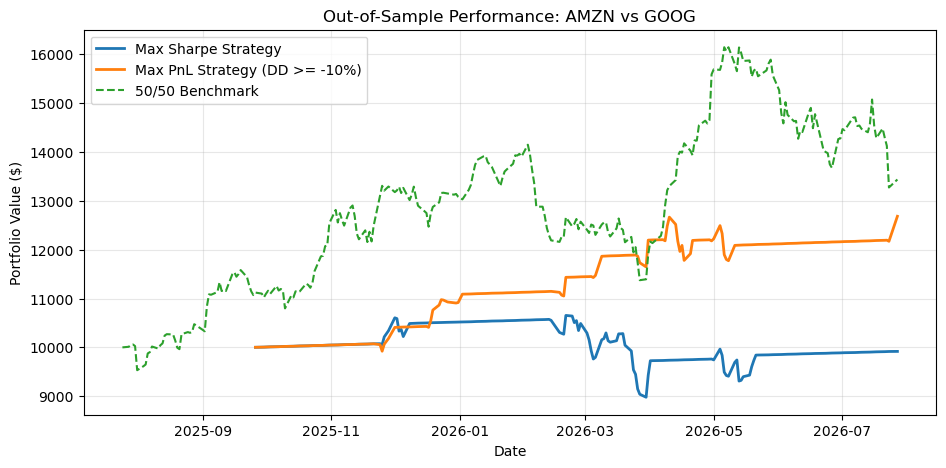

In [15]:
parameter_values={'entry': [1.25, 1.50, 1.75, 2.00, 2.25],'exit': [0.0, 0.25, 0.50],'z_window': [20, 30, 45, 60],
              'delta_beta': [1e-5, 1e-4, 1e-3],'stop': [3.0, 3.5, 4.0],}
train_results = parasearch(stockxlogged,stockylogged, parameters=parameter_values)
test_stockxlogged=TestMatrixLog['AMZN']
test_stockylogged=TestMatrixLog['GOOG']

#Extract Best Parameter Sets for Max Sharpe/PnL
train_results['Sharpe_num'] = train_results['Sharpe Ratio'].astype(float)
train_results['PnL_num'] = train_results['Net PnL'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
train_results['MDD_num'] = train_results['Max Drawdown'].str.replace('%', '', regex=False).astype(float)

best_sharpe = train_results.sort_values('Sharpe_num', ascending=False).iloc[0].to_dict()
best_pnl = train_results[train_results['MDD_num'] >= -10.0].sort_values('PnL_num', ascending=False).iloc[0].to_dict()

#function for ease of calculations
def run_test_strategy(params,train_x,train_y,test_x,test_y):
    w = int(params['z_window'])
    _, _, _, _, train_state = kalman_filter(train_x, train_y, delta_beta=params['delta_beta'], z_window=w)
    a_ts, b_ts, _, z_ts, _ = kalman_filter(test_x, test_y,delta_beta=params['delta_beta'],z_window=w,warmup=0, **train_state)   
    pos_ts = signals(z_ts, entry=params['entry'], exit=params['exit'], stop=params['stop'])
    return returns(test_x, test_y, pos_ts, a_ts, b_ts, capital=10000)['Portfolio Value']

# Run Backtests
ret_sharpe = run_test_strategy(best_sharpe, stockxlogged, stockylogged, test_stockxlogged, test_stockylogged)
ret_pnl = run_test_strategy(best_pnl, stockxlogged, stockylogged, test_stockxlogged, test_stockylogged)

#Compute 50/50 benchmark
px, py = np.exp(test_stockxlogged), np.exp(test_stockylogged)
benchmark = 5000 * (px / px.iloc[0]) + 5000 * (py / py.iloc[0])

plt.figure(figsize=(11, 5))
plt.plot(ret_sharpe, label='Max Sharpe Strategy', linewidth=2)
plt.plot(ret_pnl, label='Max PnL Strategy (DD >= -10%)', linewidth=2)
plt.plot(benchmark, label='50/50 Benchmark', linestyle='--', linewidth=1.5)
plt.title('Out-of-Sample Performance: AMZN vs GOOG')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()